In [32]:
import numpy as np
import math
import matplotlib.pyplot as plt

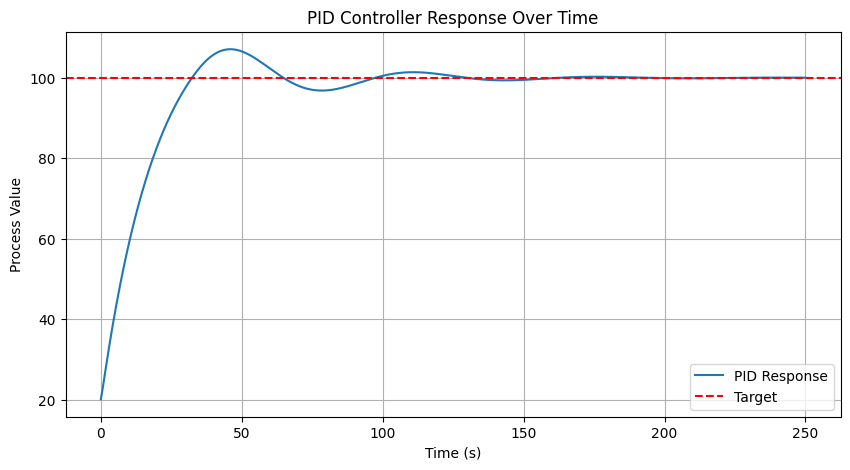

In [33]:
class PID:
    def __init__(self, kp, ki, kd):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.integral = 0
        self.previous_error = 0

    def compute_PID(self, current, target, dt):
        error = target - current
        self.integral += error * dt
        # clamp integral to avoid windup
        self.integral = max(min(self.integral, 100), -100)
        derivative = (error - self.previous_error) / dt
        self.previous_error = error
        return self.kp*error + self.ki*self.integral + self.kd*derivative

# PID parameters
pid = PID(kp=0.05, ki=0.01, kd=0.001)
current = 20
target = 100
dt = 0.01
steps = 25000
# Store data for plotting
time = []
values = []
for i in range(steps):
    pid_c = pid.compute_PID(current, target, dt)
    current += pid_c * dt
    time.append(i*dt)
    values.append(current)

# Plot the response
plt.figure(figsize=(10,5))
plt.plot(time, values, label='PID Response')
plt.axhline(target, color='r', linestyle='--', label='Target')
plt.xlabel('Time (s)')
plt.ylabel('Process Value')
plt.title('PID Controller Response Over Time')
plt.legend()
plt.grid(True)
plt.show()


In [34]:
class PID:
    def __init__(self, kp, ki, kd, integral_limit=None):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.integral = 0
        self.previous_error = 0
        self.integral_limit = integral_limit  # avoid windup

    def compute(self, current, target, dt):
        error = target - current
        self.integral += error * dt
        if self.integral_limit:
            self.integral = max(min(self.integral, self.integral_limit), -self.integral_limit)
        derivative = (error - self.previous_error) / dt
        self.previous_error = error
        return self.kp*error + self.ki*self.integral + self.kd*derivative

# PID gains for roll and pitch
roll_pid = PID(kp=1.0, ki=0.1, kd=0.05, integral_limit=10)
pitch_pid = PID(kp=1.0, ki=0.1, kd=0.05, integral_limit=10)
# initial angles (degrees)
roll_current = 5
pitch_current = 5
roll_target = 100
pitch_target = 594
dt = 0.01

# simulation loop
for i in range(5000):
    roll_control = roll_pid.compute(roll_current, roll_target, dt)
    pitch_control = pitch_pid.compute(pitch_current, pitch_target, dt)
    # update angles (simplified physics)
    roll_current += roll_control * dt
    pitch_current += pitch_control * dt

print(f"Step {i}: Roll={roll_current:.2f}, Pitch={pitch_current:.2f}")


Step 4999: Roll=100.01, Pitch=594.01


In [3]:
for i in range(3):
  print(f"x{i}")

t=['u','i','o']
u=[1,2,3]
for t, u in zip(t, u):
  print(f"{t} {u}")

x0
x1
x2
u 1
i 2
o 3
